In [57]:
import numpy as np
import netket as nk
import numpy as np
import matplotlib.pyplot as plt
import json
from pyscf import gto, scf, fci
import netket.experimental as nkx
from tqdm import tqdm

bond_distance = np.round(np.linspace(0.2,2.7,20),2)

In [58]:
H2_E_FCI = []
H2_E_HF = []
H2_nuclear_repulsion = []
for bond_length in tqdm(bond_distance):
    geometry = [
        ('H', (0., 0., 0.)),
        ('H', (bond_length, 0., 0.)),
    ]

    # 创建分子对象，使用STO-3G基组
    mol = gto.M(atom=geometry, basis='STO-3G')

    # 进行Hartree-Fock计算
    mf = scf.RHF(mol).run(verbose=0)
    E_hf = mf.e_tot
    nuclear_repulsion = mol.energy_nuc()
    H2_nuclear_repulsion.append(nuclear_repulsion)
    
    # 进行FCI计算作为参考
    cisolver = fci.FCI(mf)
    E_fci, fcivec = cisolver.kernel()
    H2_E_FCI.append(E_fci)
    H2_E_HF.append(E_hf)
    
with open('H2_E_FCI_HF.npz', 'wb') as f:
    np.savez(f, E_FCI=H2_E_FCI, E_HF=H2_E_HF,E_nuclear_repulsion=H2_nuclear_repulsion, bond_length=bond_distance)
    

100%|██████████| 20/20 [00:00<00:00, 42.27it/s]


VMC计算

In [ ]:
hi = nk.hilbert.SpinOrbitalFermions(
    n_orbitals=2,  # 总空间轨道数
    s = 1/2,
    n_fermions_per_spin=(1, 1)  # 每种自旋的电子数
)
cluster = [(0,1),(2,3)]
g = nk.graph.Graph(edges=[(0,1),(2,3)])
sa = nk.sampler.MetropolisFermionHop(
    hi, graph=g, n_chains=16, spin_symmetric=True, sweep_size=64
)

In [23]:
import jax
import jax.numpy as jnp
from flax import nnx

class FFN(nnx.Module):

    def __init__(self, N: int, alpha: int = 1, *, rngs: nnx.Rngs):
        self.alpha = alpha
        self.linear = nnx.Linear(in_features=N, out_features=alpha * N, rngs=rngs,param_dtype=complex)

    def __call__(self, x: jax.Array):
        y = self.linear(x)
        y = nnx.relu(y)
        return jnp.sum(y, axis=-1)

N = 4
ffnn_model = FFN(N=N, alpha=1, rngs=nnx.Rngs(2))
vs = nk.vqs.MCState(sa, ffnn_model, n_discard_per_chain=10, n_samples=512)

# 设置优化器
opt = nk.optimizer.Sgd(learning_rate=0.05)
sr = nk.optimizer.SR(diag_shift=0.01)

FFNN的计算结果

In [24]:
ffnn_energy=[]
for bond_length in tqdm(bond_distance):
    geometry = [
        ('H', (0., 0., 0.)),
        ('H', (bond_length, 0., 0.)),
    ]
    # 创建分子对象，使用STO-3G基组
    mol = gto.M(atom=geometry, basis='STO-3G')
    ha = nkx.operator.from_pyscf_molecule(mol)
    gs = nk.driver.VMC(ha, opt, variational_state=vs, preconditioner=sr)
    gs.run(200)
    ffnn_energy.append(gs.energy.mean)

  0%|          | 0/20 [00:00<?, ?it/s]/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/netket/optimizer/qgt/qgt_onthefly.py:139: HolomorphicUndeclaredWarning: 
Defaulting to `holomorphic=False`, but this might lead to increased
computational cost or disabled features. Check if your variational
function is holomorphic, and if so specify `holomorphic=True`as an extra
keyword argument.

To silence this warning, specify the `holomorphic=False/True` keyword
argument.

To numerically check whether your variational function is or not holomorphic
you can use the following snippet:

```python
   vs = nk.vqs.MCState(...)

   nk.utils.is_probably_holomorphic(vs._apply_fun, vs.parameters, vs.samples, vs.model_state)
```

if `nk.utils.is_probably_holomorphic` returns False, then your function is not holomorphic.
If it returns True, it is probably holomorphic.


-------------------------------------------------------
For more detailed informations, visit the following link:
	 https://netket.

In [26]:
ffnn_energy

[Array(-1.02890445+1.66950284e-07j, dtype=complex128),
 Array(-1.00681734+5.17307581e-11j, dtype=complex128),
 Array(-1.03004448-3.14940893e-16j, dtype=complex128),
 Array(-1.01002066-5.5530268e-18j, dtype=complex128),
 Array(-1.00981765-1.46189057e-17j, dtype=complex128),
 Array(-0.98586052+5.63041802e-18j, dtype=complex128),
 Array(-0.98964224-8.38833015e-18j, dtype=complex128),
 Array(-0.98390132-5.65245659e-18j, dtype=complex128),
 Array(-0.96755648-5.88857664e-18j, dtype=complex128),
 Array(-0.9608972-3.65919478e-18j, dtype=complex128),
 Array(-0.9575557-1.62125293e-18j, dtype=complex128),
 Array(-0.93047668+1.15236043e-17j, dtype=complex128),
 Array(-0.93345595+5.12578674e-18j, dtype=complex128),
 Array(-0.95039302-5.18097724e-18j, dtype=complex128),
 Array(-0.93656161-8.79387275e-18j, dtype=complex128),
 Array(-0.9221192+1.63116314e-18j, dtype=complex128),
 Array(-0.91019345+1.14925867e-18j, dtype=complex128),
 Array(-0.91279173+1.43545813e-18j, dtype=complex128),
 Array(-0.9025

In [27]:
with open('H2_FFNN.npz', 'wb') as f:
    np.savez(f, E_FFNN=ffnn_energy, bond_length=bond_distance)

In [53]:
# with open('H2_FFNN.npz', 'rb') as f:
#     data = np.load(f)
#     E_FFNN = data['E_FFNN']
#     bond_length = data['bond_length']
    
with open('H2_E_FCI_HF.npz', 'rb') as f:
    data = np.load(f)
    E_FCI = data['E_FCI']      # 不是 E_fci
    E_HF = data['E_HF']
    E_nuclear_repulsion = data['E_nuclear_repulsion']
    bond_length = data['bond_length']

In [47]:
E_FCI

array([-1.05674075, -1.05012956, -1.04578314, -1.03937452, -1.03311977,
       -1.02904565, -1.02309128, -1.01923295, -1.01362208, -1.00823267,
       -1.004767  , -0.99976413, -0.9949998 , -0.99195733, -0.98759478,
       -0.98482015, -0.98085713, -0.97712962, -0.97477309, -0.97142669])

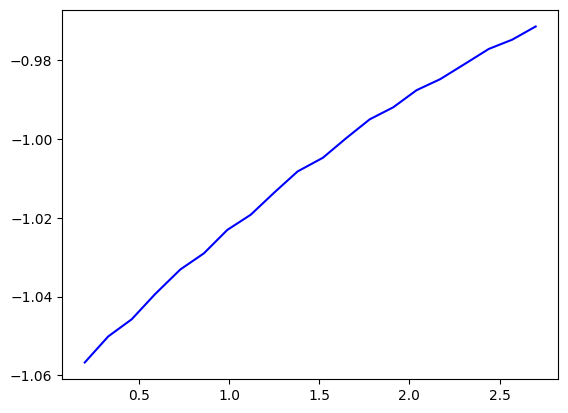

In [60]:
import matplotlib.pyplot as plt

plt.plot(bond_distance,E_FCI , 'b-', label="FFNN energy")

/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24635 (\N{CJK UNIFIED IDEOGRAPH-603B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 33021 (\N{CJK UNIFIED IDEOGRAPH-80FD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20320 (\N{CJK UNIFIED IDEOGRAPH-4F60}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 

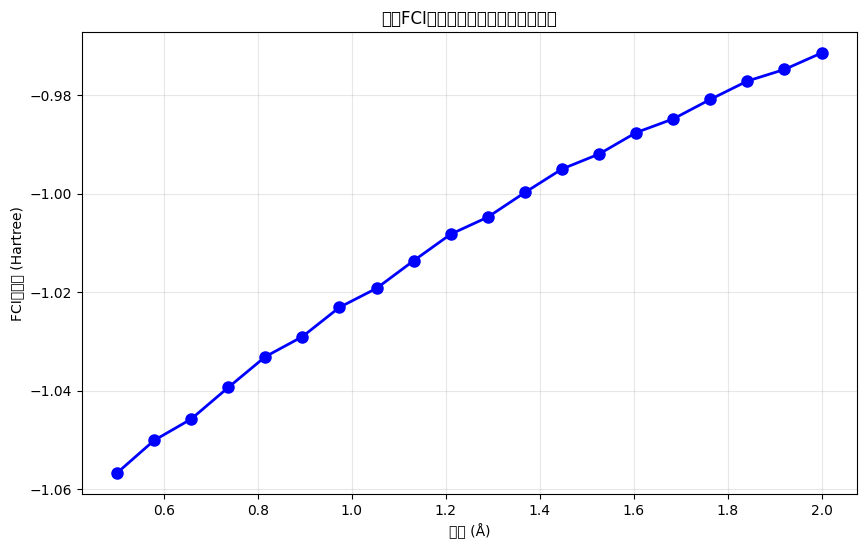

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

bond_length = np.linspace(0.5, 2.0, 20)  # 示例键长

plt.figure(figsize=(10, 6))
plt.plot(bond_length, E_FCI, 'bo-', linewidth=2, markersize=8)
plt.xlabel('键长 (Å)')
plt.ylabel('FCI总能量 (Hartree)')
plt.title('你的FCI势能面（可能键长范围不对）')
plt.grid(True, alpha=0.3)
plt.show()